In [7]:
!pip install mysql-connector-python
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB 991.0 kB/s eta 0:00:17
   ---------------------------------------- 0.1/16.4 MB 1.1 MB/s eta 0:00:16
   ---------------------------------------- 0.1/16.4 MB 1.2 MB/s eta 0:00:14
    --------------------------------------- 0.3/16.4 MB 1.4 MB/s eta 0:00:12
    --------------------------------------- 0.3/16.4 MB 1.4 MB/s eta 0:00:12
   - -------------------------------------- 0.4/16.4 MB 1.6 MB/s eta 0:00:10
   - -------------------------------------- 0.6/16.4 MB 1.9 MB/s eta 0:00:09
   - -------------------------------------- 0.7/16.4 MB 2.0 MB/s eta 0:00:08
   -- ------------------------------------- 0.8/16.4 MB 2.2 MB/s eta 0:00:08
   -- ------------------------------------- 1.0/16.4 MB 2.3 MB/s eta 0:00:07
   -- ------------------------------------- 1.1/16.4 MB 2.3 MB/s eta 0:00:07
   -- ------------------------------------- 1.2/16.4 MB 2.3 MB/s eta 0:00:07
   -

In [25]:
db = mysql.connector.connect(
    host = 'localhost',
    user =  'root',
    password = 'ABUabdullah@26',
    database =  'online_sales',
    use_pure = True
)


cursor = db.cursor()
cursor.execute("SHOW TABLES")
tables = cursor.fetchall()
print("Tables in the database:")
for table in tables:
    print(table[0])
cursor.close()

Tables in the database:
product
product1
product_demo
sales
transactions


True

In [27]:
cursor = db.cursor(dictionary=True)
cursor.execute("SELECT * FROM sales LIMIT 5")
sample_data = cursor.fetchall()

print("\nSample sales data:")
for row in sample_data:
    print(row)
cursor.close()


Sample sales data:
{'row_id': 1, 'order_id': 3, 'order_date': datetime.date(2010, 10, 13), 'order_priority': 'Low', 'order_quantity': 6, 'sales': 261.54}
{'row_id': 2, 'order_id': 293, 'order_date': datetime.date(2012, 10, 1), 'order_priority': 'High', 'order_quantity': 49, 'sales': 10123.0}
{'row_id': 3, 'order_id': 483, 'order_date': datetime.date(2011, 7, 10), 'order_priority': 'High', 'order_quantity': 27, 'sales': 244.57}
{'row_id': 4, 'order_id': 383, 'order_date': datetime.date(2010, 8, 10), 'order_priority': 'High', 'order_quantity': 30, 'sales': 4965.75}
{'row_id': 5, 'order_id': 515, 'order_date': datetime.date(2010, 8, 28), 'order_priority': 'low', 'order_quantity': 19, 'sales': 394.27}


True

In [31]:
query1 = """SELECT order_id, 
SUM(order_quantity) AS total_qty, 
SUM(order_quantity * sales) AS revenue 
FROM sales GROUP BY order_id"""
products_df = pd.read_sql(query1, db)
print("=== Sales by Product ===")
print(products_df)

=== Sales by Product ===
   order_id  total_qty        revenue
0         3        6.0    1569.240051
1       293       49.0  496027.957031
2       483       27.0    6603.390198
3       383       30.0  148972.500000
4       515       19.0    7491.129791
5       613       21.0    3081.750000
6       633       23.0    2151.420021
7       643       21.0   19019.700256
8       678       44.0   10050.040161


<Figure size 1000x600 with 0 Axes>

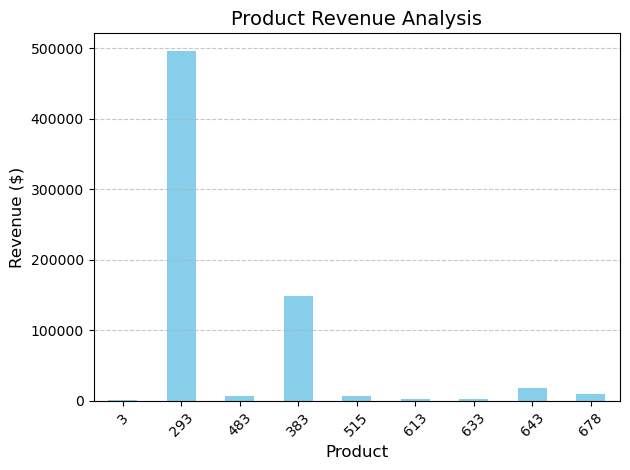

In [34]:
plt.figure(figsize=(10, 6))
products_df.plot(kind='bar', x='order_id', y='revenue', legend=False, color='skyblue')
plt.title('Product Revenue Analysis', fontsize=14)
plt.xlabel('Product', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save and show
plt.savefig('product_revenue.png', dpi=300)
plt.show()